<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 09</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Explainability</div><div style="font-size:1.05em;opacity:0.85">What the deployed model looks at, overall and for one customer.</div></div>

Stage 08 showed that LightGBM + season ranks well and stays calibrated. A retention manager
still has to trust *why* a customer is flagged before paying for an incentive. This stage
explains the deployed model with **SHAP** (TreeSHAP, exact for trees): each prediction is split
into one additive contribution per feature, in log-odds of the model's raw score. It looks at
the model overall, at the shape of its main effects, at what it learned about the calendar, and
at two individual customers.

**Pipeline rule.** Explanations come from `churnvalue.explain`, the same functions
`churnvalue export` uses to ship each customer's top reasons to the web app; this notebook
plots them. SHAP explains the uncalibrated score: calibration is monotone, so it changes the
scale of a prediction but not which features pushed it up or down.

| | |
|---|---|
| **Input** | `data/interim/snapshots.parquet` · `models/lightgbm_seasonal.joblib` · `reports/evaluation.json` |
| **Outputs** | `reports/results/09_summary.json` · `reports/figures/09_*.png` |
| **Parameters** | `configs/default.yaml` → `training.deployed_model`, `economics` |
| **Shared code** | `churnvalue.explain` · `churnvalue.models` · `churnvalue.evaluate` · `churnvalue.economics` · `churnvalue.calibration` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">X1 global</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">X2 direction</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">X3 shape</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">X4 the calendar</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">X5 two customers</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from churnvalue.calibration import calibrator_from_dict
from churnvalue.config import load_config, project_root
from churnvalue.economics import expected_profit
from churnvalue.evaluate import frame_economics, temporal_split
from churnvalue.explain import cutoff_baseline, explain, global_importance
from churnvalue.features import CONTEXT_FEATURES
from churnvalue.models import SUPERVISED, feature_matrix, predict_churn
from churnvalue.reporting import StageSummary
from churnvalue.training import load_estimator
from churnvalue.viz import style
from churnvalue.viz.style import INK, MUTED, NEUTRAL, RETAINED, SEQUENTIAL

os.chdir(project_root())
CFG = load_config()
STAGE, FIGURES, RESULTS = "09", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


snapshots = pd.read_parquet(CFG.data.interim_dir / "snapshots.parquet")
split = temporal_split(snapshots, CFG)
SPEC = SUPERVISED[CFG.training.deployed_model]
estimator = load_estimator(CFG.models_dir, SPEC.name)
report = json.loads((CFG.reports_dir / "evaluation.json").read_text(encoding="utf-8"))
calibrator = calibrator_from_dict(report["models"][SPEC.name]["calibrator"])
test = snapshots[snapshots["cutoff"] == split.test].reset_index(drop=True)
x_test = feature_matrix(test, SPEC)
explanation = explain(estimator, x_test, SPEC.features)
shap_frame = explanation.frame()
CUSTOMER = [f for f in SPEC.features if f not in CONTEXT_FEATURES]

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">X1 · Global</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">a quarter of the model's attention goes to the calendar</span></div>

Mean absolute SHAP ranks the features by how much they move predictions on the test cutoff.
Two things stand out. The **purchase history** — how many days a customer has bought on, and
at what cadence — carries most of the signal. And the two **cutoff-month** features together
account for about a quarter of the total: on a single cutoff they move every customer alike,
which is exactly the seasonal level shift that stage 08 needed.

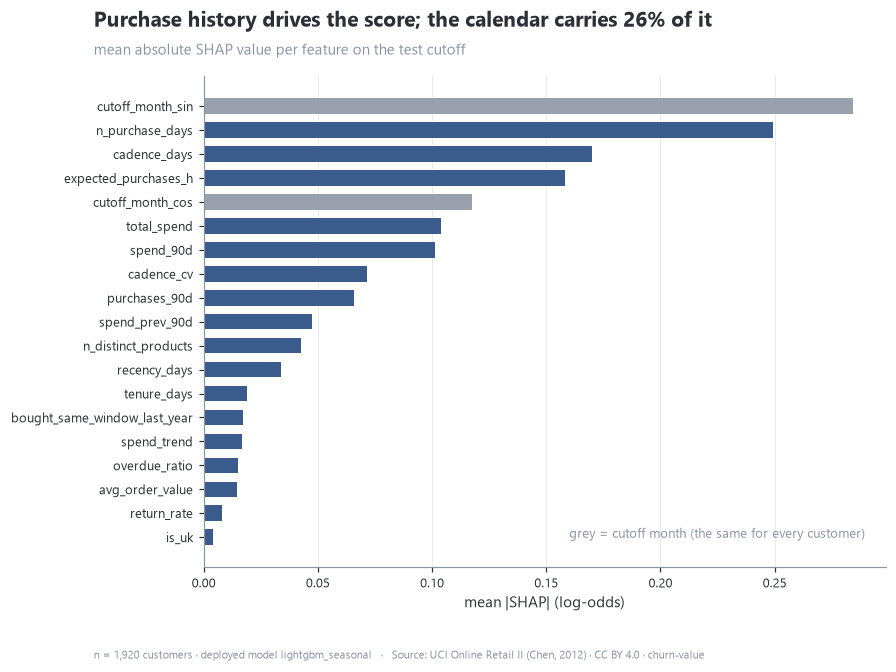

In [2]:
importance = global_importance(explanation)
S["importance"] = importance.to_dict()
S["context_share"] = importance[list(CONTEXT_FEATURES)].sum() / importance.sum()
fig, ax = plt.subplots(figsize=(8, 5.8))
ordered = importance.iloc[::-1]
colors = [RETAINED if f in CONTEXT_FEATURES else NEUTRAL for f in ordered.index]
ax.barh(ordered.index, ordered.values, color=colors, height=0.65)
ax.grid(axis="y", visible=False)
ax.set_xlabel("mean |SHAP| (log-odds)")
ax.text(
    0.97,
    0.06,
    "grey = cutoff month (the same for every customer)",
    transform=ax.transAxes,
    ha="right",
    fontsize=8.5,
    color=MUTED,
)
style.headline(
    fig,
    f"Purchase history drives the score; the calendar carries {S['context_share']:.0%} of it",
    "mean absolute SHAP value per feature on the test cutoff",
)
style.add_source(fig, f"n = {len(test):,} customers · deployed model {SPEC.name}")
save(fig, "importance")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">X2 · Direction</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">each dot is a customer, coloured by the feature's value</span></div>

A summary ("beeswarm") plot shows direction as well as size: for each customer feature, every
customer is a dot placed at its SHAP value and coloured by where the feature's value sits in
its own distribution. **Many purchase days, high spend and frequent recent purchases push churn
down** (dark dots on the left); a **long cadence pushes it up**. The overdue ratio, the idea the
origin project was built on, barely moves the model — stage 04 showed why: eligibility already
absorbs lateness.

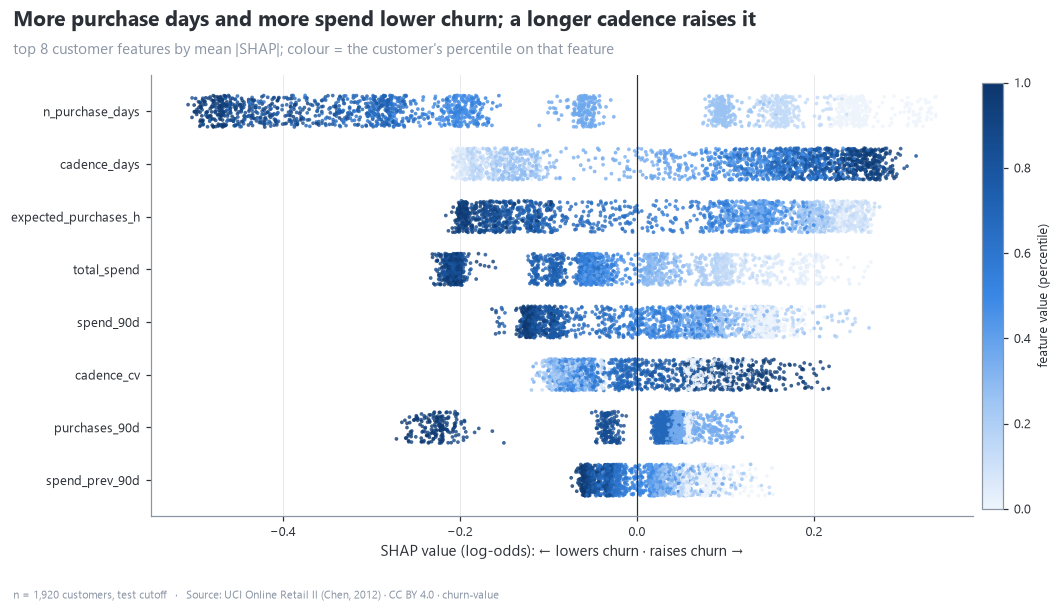

{'n_purchase_days': -0.98, 'cadence_days': 0.94, 'expected_purchases_h': -0.96, 'total_spend': -0.97, 'spend_90d': -0.94, 'cadence_cv': 0.38, 'purchases_90d': -0.84, 'spend_prev_90d': -0.93, 'overdue_ratio': -0.12}


In [3]:
top = [f for f in importance.index if f in CUSTOMER][:8]
fig, ax = plt.subplots(figsize=(10, 5.2))
rng = np.random.default_rng(0)
for row, feature in enumerate(reversed(top)):
    values = shap_frame[feature].to_numpy()
    quantile = test[feature].rank(pct=True).to_numpy()
    jitter = rng.uniform(-0.3, 0.3, values.size)
    ax.scatter(values, row + jitter, c=quantile, cmap=SEQUENTIAL, s=6, alpha=0.8, linewidths=0)
ax.axvline(0, color=INK, lw=0.8)
ax.set_yticks(range(len(top)), list(reversed(top)))
ax.grid(axis="y", visible=False)
ax.set_xlabel("SHAP value (log-odds): ← lowers churn · raises churn →")
colorbar = fig.colorbar(plt.cm.ScalarMappable(cmap=SEQUENTIAL), ax=ax, fraction=0.025, pad=0.01)
colorbar.set_label("feature value (percentile)", fontsize=8.5)
rank_corr = {f: float(spearmanr(test[f], shap_frame[f]).statistic) for f in CUSTOMER}
S["rank_correlation_value_vs_shap"] = rank_corr
style.headline(
    fig,
    "More purchase days and more spend lower churn; a longer cadence raises it",
    "top 8 customer features by mean |SHAP|; colour = the customer's percentile on that feature",
)
style.add_source(fig, f"n = {len(test):,} customers, test cutoff")
save(fig, "beeswarm")
plt.show()
print({f: round(rank_corr[f], 2) for f in [*top, "overdue_ratio"]})

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">X3 · Shape</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the effects are monotone and saturate</span></div>

The two strongest customer features, drawn against their own values. The effect of purchase
days falls steeply over the first handful and then flattens: a customer's fifth purchase day
says more than their fiftieth. Cadence works the other way, with little change below about a
month and a clear rise for customers who buy every two months or less often. Both shapes are
plausible, which is a check on the model as much as an explanation of it.

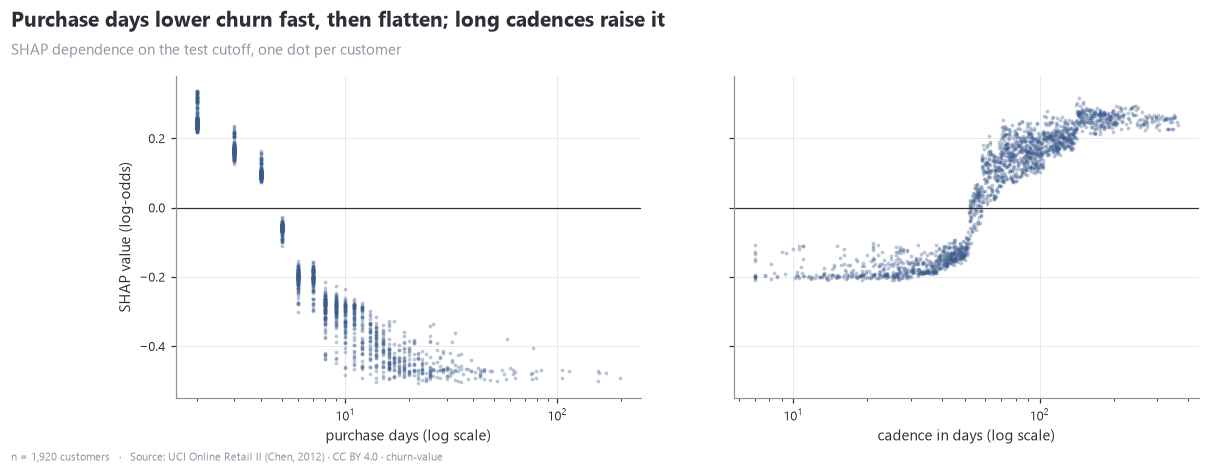

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, feature, label in [
    (axes[0], "n_purchase_days", "purchase days (log scale)"),
    (axes[1], "cadence_days", "cadence in days (log scale)"),
]:
    ax.scatter(test[feature], shap_frame[feature], s=6, color=NEUTRAL, alpha=0.35, linewidths=0)
    ax.set_xscale("log")
    ax.axhline(0, color=INK, lw=0.8)
    ax.set_xlabel(label)
axes[0].set_ylabel("SHAP value (log-odds)")
buckets = pd.cut(test["n_purchase_days"], [1, 2, 3, 5, 10, 20, 10_000])
S["shap_by_purchase_days"] = {
    str(k): v
    for k, v in shap_frame.groupby(buckets.values, observed=True)["n_purchase_days"].mean().items()
}
style.headline(
    fig,
    "Purchase days lower churn fast, then flatten; long cadences raise it",
    "SHAP dependence on the test cutoff, one dot per customer",
)
style.add_source(fig, f"n = {len(test):,} customers")
save(fig, "dependence")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">X4 · The calendar</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">what the model learned about each month</span></div>

Averaging the two month contributions over the customers of each cutoff gives the model's
seasonal adjustment, in log-odds. It follows the churn calendar: strongly negative for the
August and September cutoffs, when few customers churn, and positive in December and January,
when many do. **April and May never appear in the training cutoffs**: the trees group them with
June and give all three almost the same adjustment. On the test cutoff, the adjustment is what
lowers September's predictions from June's level to the right one.

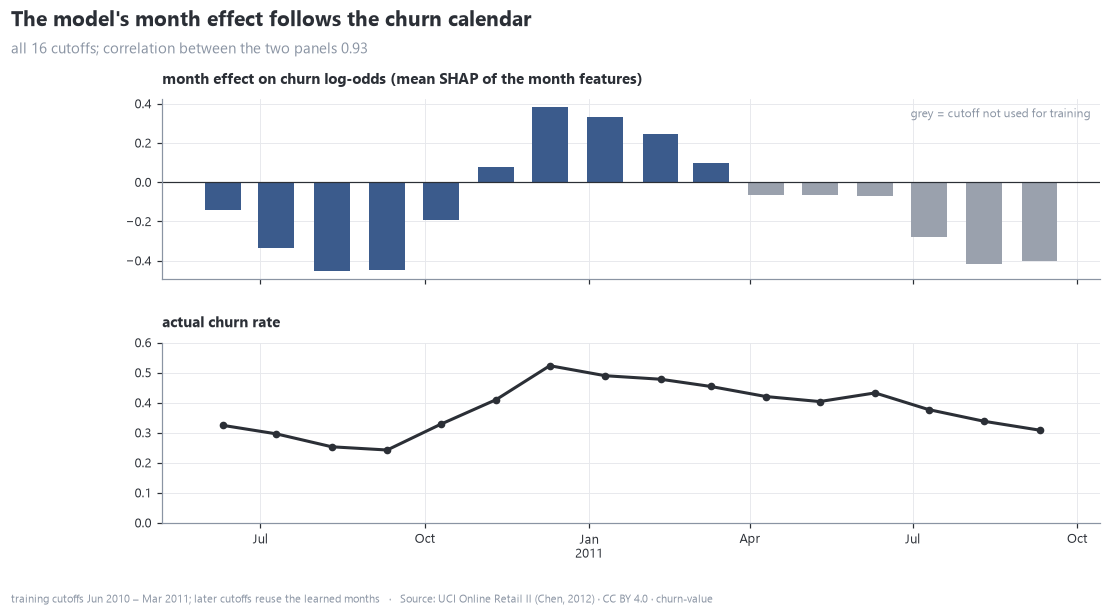

In [5]:
rows = []
for cutoff in sorted(snapshots["cutoff"].unique()):
    frame = snapshots[snapshots["cutoff"] == cutoff]
    ex = explain(estimator, feature_matrix(frame, SPEC), SPEC.features)
    context = ex.values[:, [SPEC.features.index(f) for f in CONTEXT_FEATURES]].sum(axis=1)
    rows.append(
        {
            "cutoff": pd.Timestamp(cutoff),
            "month_effect": context.mean(),
            "churn_rate": frame["churn"].mean(),
            "trained": cutoff in split.train,
        }
    )
calendar = pd.DataFrame(rows)
S["month_effect"] = calendar.set_index("cutoff")["month_effect"].to_dict()
S["month_effect_vs_churn_corr"] = float(
    np.corrcoef(calendar["month_effect"], calendar["churn_rate"])[0, 1]
)
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True, gridspec_kw={"hspace": 0.35})
ax = axes[0]
ax.bar(
    calendar["cutoff"],
    calendar["month_effect"],
    width=20,
    color=[NEUTRAL if t else RETAINED for t in calendar["trained"]],
)
ax.axhline(0, color=INK, lw=0.8)
ax.set_title("month effect on churn log-odds (mean SHAP of the month features)", fontsize=9.5)
ax.text(
    0.99,
    0.9,
    "grey = cutoff not used for training",
    transform=ax.transAxes,
    ha="right",
    fontsize=8,
    color=MUTED,
)
ax = axes[1]
ax.plot(calendar["cutoff"], calendar["churn_rate"], "o-", color=INK, markersize=4)
ax.set_title("actual churn rate", fontsize=9.5)
ax.set_ylim(0, 0.6)
style.date_axis(ax)
style.headline(
    fig,
    "The model's month effect follows the churn calendar",
    f"all 16 cutoffs; correlation between the two panels {S['month_effect_vs_churn_corr']:.2f}",
)
style.add_source(
    fig, "training cutoffs Jun 2010 – Mar 2011; later cutoffs reuse the learned months"
)
save(fig, "calendar")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">X5 · Two customers</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">a good call and a false alarm</span></div>

The web app's customer drawer shows the same breakdown for any customer. Two examples from
the test cutoff, both contacted by the deployed policy:

- the **contacted churner with the highest expected profit** — a correct and valuable call;
- the **contacted customer with the highest churn probability who kept buying** — a false
  alarm, and the kind of mistake the incentive cost pays for.

Each bar is one feature's contribution; they start from the model's average log-odds and add
up to the customer's score. The month features are folded into the starting bar, since every
customer at this cutoff shares them.

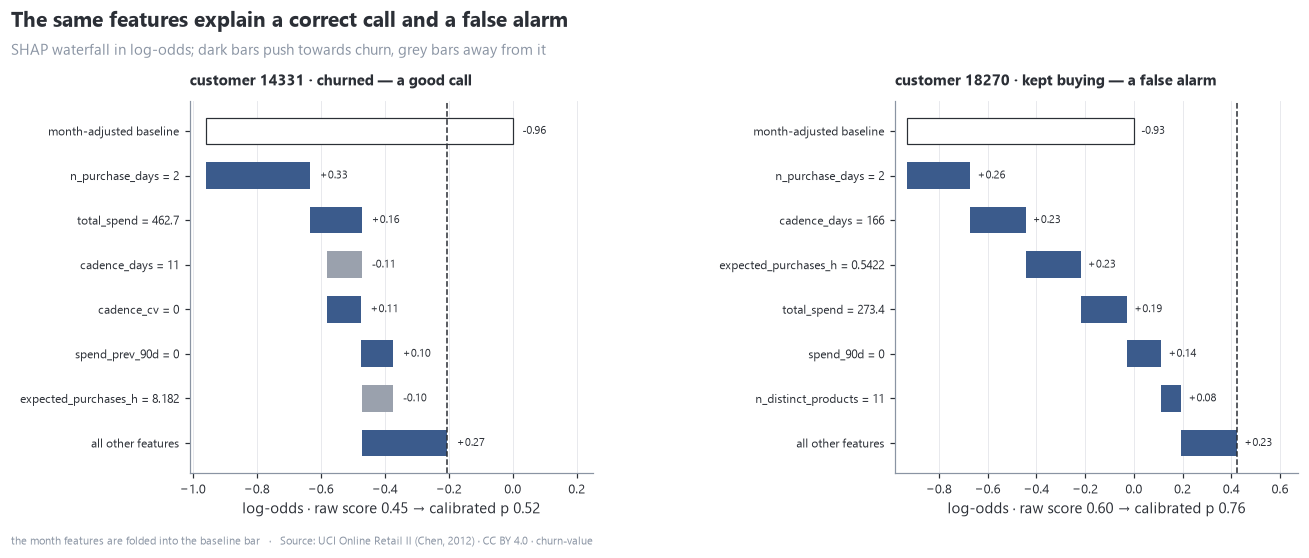

In [6]:
econ = frame_economics(test, CFG.economics)
p_test = calibrator.transform(predict_churn(estimator, test, SPEC))
exp_profit = expected_profit(p_test, econ, CFG.economics)
contacted = exp_profit > 0
churned = test["churn"].to_numpy() == 1
good = int(np.argmax(np.where(contacted & churned, exp_profit, -np.inf)))
false_alarm = int(np.argmax(np.where(contacted & ~churned, p_test, -np.inf)))
baseline = cutoff_baseline(explanation)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"wspace": 0.75})
cases = {}
for ax, index, key, title in [
    (axes[0], good, "good_call", "churned — a good call"),
    (axes[1], false_alarm, "false_alarm", "kept buying — a false alarm"),
]:
    contributions = pd.Series(shap_frame.loc[index, CUSTOMER].to_numpy(), index=CUSTOMER)
    top_features = contributions.abs().sort_values(ascending=False).index[:6]
    rest = contributions.drop(top_features).sum()
    steps = [("month-adjusted baseline", baseline[index])]
    steps += [(f"{f} = {test.loc[index, f]:,.4g}", contributions[f]) for f in top_features]
    steps.append(("all other features", rest))
    start = 0.0
    ends = []
    for y, (_, value) in enumerate(steps):
        left = 0.0 if y == 0 else start
        if y == 0:
            ax.barh(y, value, left=0.0, color="white", edgecolor=INK, height=0.6, lw=0.8)
        else:
            ax.barh(y, value, left=left, color=NEUTRAL if value > 0 else RETAINED, height=0.6)
        start = value if y == 0 else start + value
        ends += [left, left + value]
        ax.text(
            max(left, left + value) + 0.03, y, f"{value:+.2f}", va="center", fontsize=7.5, color=INK
        )
    ax.set_xlim(min(ends) - 0.05, max(ends) + 0.25)
    ax.set_yticks(range(len(steps)), [s[0] for s in steps], fontsize=8)
    ax.invert_yaxis()
    ax.axvline(start, color=INK, lw=1, ls="--")
    score = 1 / (1 + np.exp(-start))
    ax.set_title(f"customer {int(test.loc[index, 'customer_id'])} · {title}", fontsize=9.5)
    ax.set_xlabel(f"log-odds · raw score {score:.2f} → calibrated p {p_test[index]:.2f}")
    ax.grid(axis="y", visible=False)
    cases[key] = {
        "customer_id": int(test.loc[index, "customer_id"]),
        "p": float(p_test[index]),
        "expected_profit": float(exp_profit[index]),
        "top_feature": str(top_features[0]),
    }
S["examples"] = cases
style.headline(
    fig,
    "The same features explain a correct call and a false alarm",
    "SHAP waterfall in log-odds; dark bars push towards churn, grey bars away from it",
)
style.add_source(fig, "the month features are folded into the baseline bar")
save(fig, "customers")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">09 → 10, web app</span></div>

**Produced** — `reports/results/09_summary.json` and the figures `09_importance`,
`09_beeswarm`, `09_dependence`, `09_calendar`, `09_customers`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>The deployed model relies on purchase history (how often, at what cadence, how much) and on the calendar; its effects are monotone and plausible, and the overdue ratio barely matters.</li><li>The month effect it learned follows the churn calendar, which is the mechanism behind the calibration of stage 08.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>The web app shows, for every customer, the month-adjusted baseline and the five customer features with the largest contributions (`customers.json`), computed here with the same functions.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>10_business_value</b> — what the flagged customers are worth, and what the false alarms cost.</li><li>The web what-if (Plan 3) recomputes the probability with the ONNX model but does not recompute SHAP.</li></ul></div>

In [7]:
S.write(RESULTS)

WindowsPath('reports/results/09_summary.json')